## Average bond lifetime + bonding rate from averaging lifetime

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

f = "data/patches/0.7prodpatch_chainlength_30_patchspacing_5_N_beads_24000_gaussA_60_r0_0.25_gaussB_10_seed_12345.bin.txt"

N_patches = 4000
frame = 11

with open(f, "r") as file:
    for i in range((frame - 1) * (9 + N_patches) + 1):
        line = file.readline()
    # for i in range(9):
    print("Timestep:", file.readline())

df = pd.read_csv(f, skiprows=frame*9+(frame - 1) * N_patches, sep=' ', nrows=N_patches, header=None, names=["id", "mol", "x", "y", "z", "patch_coord", "patch_cluster"])
df.sort_values(by=["patch_coord", "id"], ascending=True, inplace=True)
print(df[df["patch_coord"] == 2])
print(df[df["patch_cluster"] == 8575])

Timestep: 100

Empty DataFrame
Columns: [id, mol, x, y, z, patch_coord, patch_cluster]
Index: []
        id  mol        x        y        z  patch_coord  patch_cluster
1489  8575  245  28.2518  3.62236  30.2707            0           8575


3891
3891
0
109


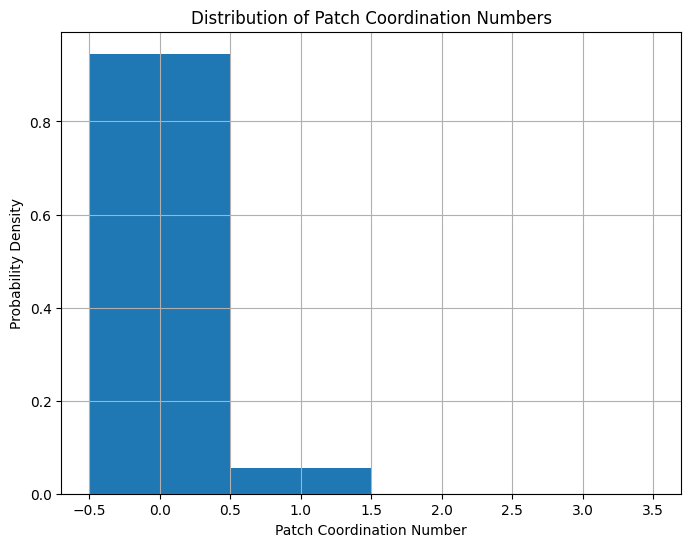

In [114]:
patch_cluster_list = np.unique(df["patch_cluster"].values)
print(len(patch_cluster_list))
cluster_size_list = np.zeros(len(patch_cluster_list))
print(len(cluster_size_list))


for i, patch_cluster in enumerate(patch_cluster_list):
    this_patch = df[df["patch_cluster"] == patch_cluster]
    # print("Patch id:", patch_cluster)
    # print(this_patch)
    cluster_size_list[i] = np.max(this_patch[["patch_coord"]].values)
    # print(f"Cluster {patch_cluster} has size {cluster_size_list[i]}")


# percentage of bonds with 3 patches
num_3_patch_bonds = np.sum(cluster_size_list == 2)
print(num_3_patch_bonds)
total_bonds = np.sum(cluster_size_list == 2) + np.sum(cluster_size_list == 1) # only consider bonds with at least 1 patch
print(total_bonds)
# percentage_3_patch_bonds = (num_3_patch_bonds / total_bonds) * 100
# print(f"Percentage of bonds with 3 patches: {percentage_3_patch_bonds:.2f}%")

# histogram of patch_coord
plt.figure(figsize=(8, 6))
plt.hist(df["patch_coord"], bins=np.arange(-0.5, 4.5, 1), density=True)
plt.title("Distribution of Patch Coordination Numbers")
plt.xlabel("Patch Coordination Number")
plt.ylabel("Probability Density")
plt.grid()
plt.show()  

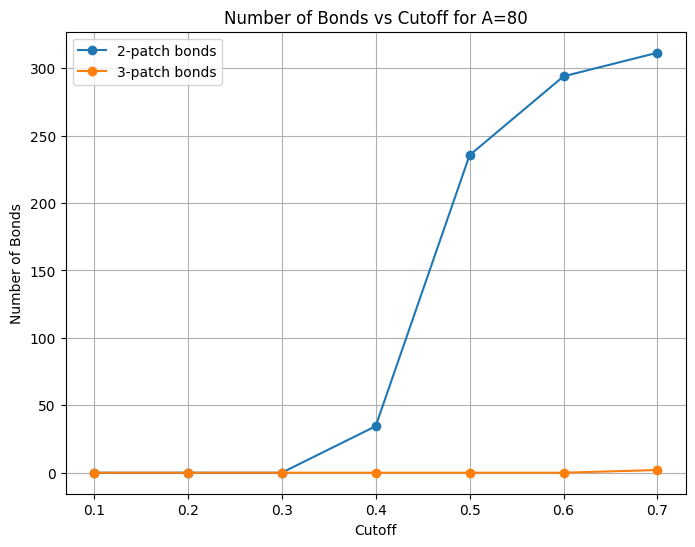

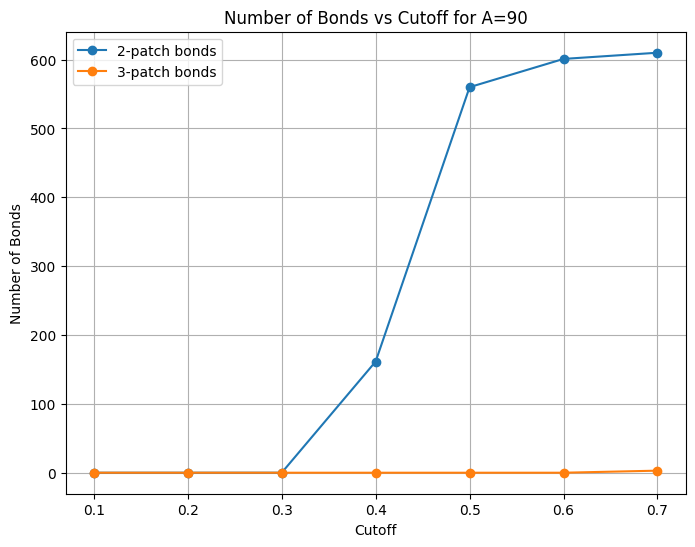

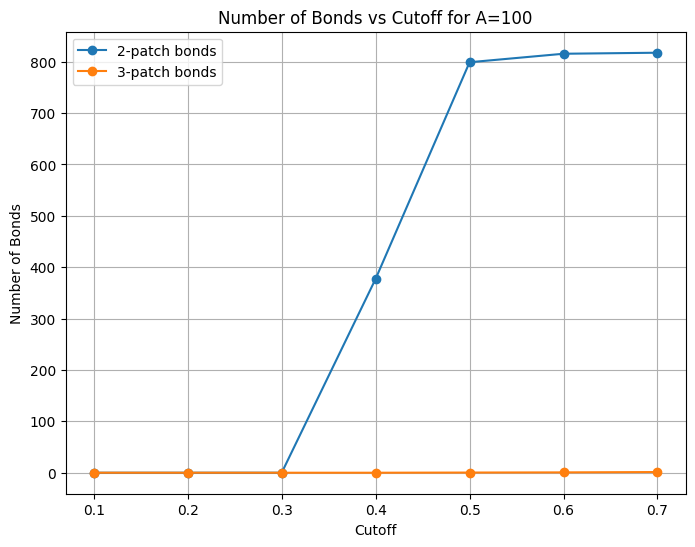

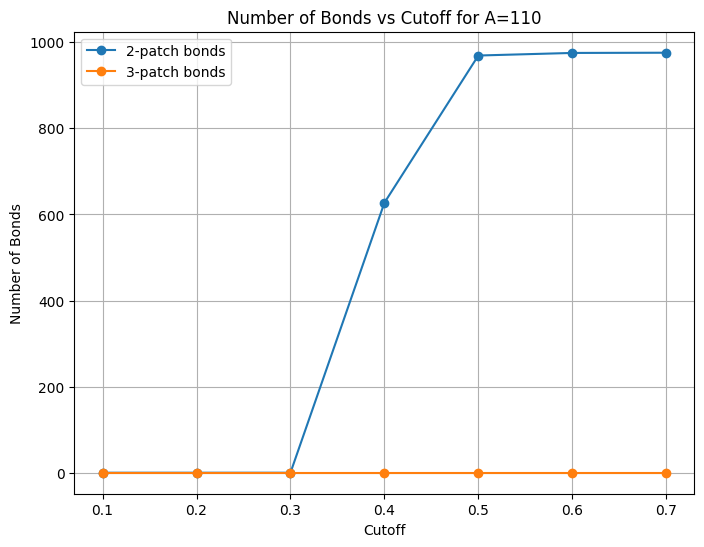

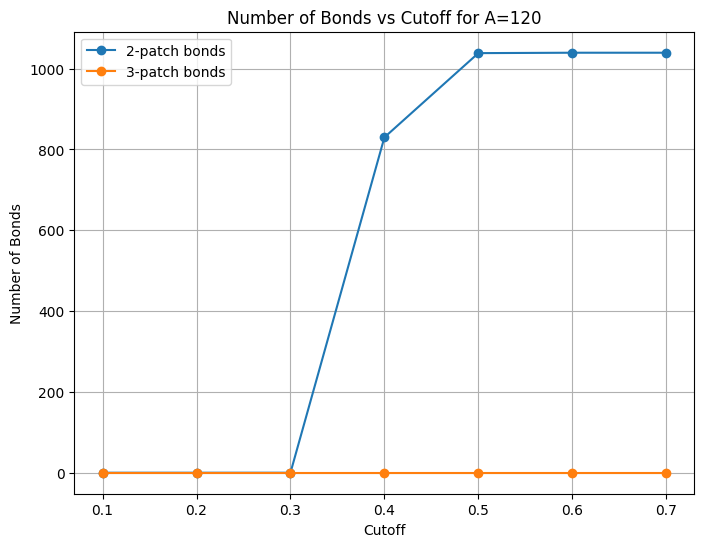

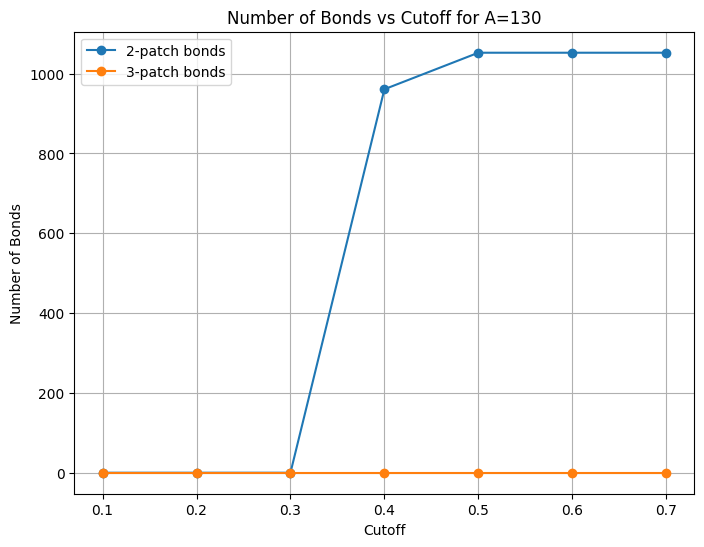

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


for A in [80, 90, 100, 110, 120, 130]:
    two_patch_bond_list = []
    three_patch_bond_list = []
    for cutoff in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
        filename = f"data/patches/{cutoff}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
        N_patches = 4000
        frame = 11

        # with open(filename, "r") as file:
        #     for i in range((frame - 1) * (9 + N_patches) + 1):
        #         line = file.readline()
        #     print("Timestep:", file.readline())

        df = pd.read_csv(filename, skiprows=frame*9+(frame - 1) * N_patches, sep=' ', nrows=N_patches, header=None, names=["id", "mol", "x", "y", "z", "patch_coord", "patch_cluster"])
        df.sort_values(by=["patch_coord", "id"], ascending=True, inplace=True)

        patch_cluster_list = np.unique(df["patch_cluster"].values)
        cluster_size_list = np.zeros(len(patch_cluster_list))

        for i, patch_cluster in enumerate(patch_cluster_list):
            this_patch = df[df["patch_cluster"] == patch_cluster]
            cluster_size_list[i] = np.max(this_patch[["patch_coord"]].values) + 1

        two_patch_bond_list.append(np.sum(cluster_size_list == 2)/2)
        three_patch_bond_list.append(np.sum(cluster_size_list == 3)/3)
    
    figure = plt.figure(figsize=(8, 6))
    plt.plot([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7], two_patch_bond_list, marker='o', label="2-patch bonds")
    plt.plot([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7], three_patch_bond_list, marker='o', label="3-patch bonds")
    plt.title(f"Number of Bonds vs Cutoff for A={A}")
    plt.xlabel("Cutoff")
    plt.ylabel("Number of Bonds")
    plt.grid()
    plt.legend()
    plt.show()

## Lifetime algorithm with different $r_{\text{on}}, r_{\text{off}}$

With different radii for forming/breaking a bond, we should avoid jitter close to one cutoff that result in tiny lifetimes. This does require generating and reading two clustering dumps, but we can dump both in one file so we at least won't have too many files.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# lifetime object:
#   - bonded_pair: (id1, id2)
#   - start_time: timestep when bond is formed
#   - end_time: timestep when bond breaks
#   - lifetime: end_time - start_time

# Read frame
# Filter only consider bonds with at least 1 patch
# sort by patch_cluster (get bonded pairs)
# Create broken flag list for all current bonded pairs
# if already existing in bonded pairs, set flag to false
# if not existing, add to bonded pairs and start counting lifetime until it breaks (patch_coord goes to 0)
# all pairs that have broken flag true, set end_time to current timestep, calculate lifetime, and remove from bonded pairs
"""
Process lifetimes from clustering data file. Each frame of the file contains the following sections:
- "ITEM: TIMESTEP" followed by the timestep on the next line
- "ITEM: NUMBER OF ATOMS" followed by the number of entries on the next line
- "ITEM: ATOMS" followed by the data lines for each entry, with 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster

The bonded_pairs list is a dictionary where the key is a tuple of (id1, id2) with id1 < id2 to avoid duplicates, and the value is the 
start_time of the bond. 

The bond_lifetimes list is a list of tuples (id1, id2, start_time, end_time, lifetime) for each bonded pair that has broken.

If there are any bonded_pairs that have not broken by the end of the dump, we ignore them and do not record a lifetime for them.

All times for breaking/creating are considered on the timestep we note them, so we should on average get the right time 
(i.e. both events are noted AFTER they happen)

Args:
    - filename: path to the clustering data file
Returns:
    - bond_lifetimes: list of tuples (id1, id2, start_time, end_time, lifetime) for each bonded pair
"""
def process_buffered_lifetimes(filename_on, filename_off, timestep=0.002):
    # init empty bond lifetime list
    bond_lifetimes = []
    # init empty bonded pair dict. lookup by (id1, id2) where id1 < id2 to avoid duplicates. value is start_time of the bond
    bonded_pairs = {}
    with open(filename_on, 'r') as f_on:
        with open(filename_off, 'r') as f_off:
            time = 0
            while True:
                # stop reading BOTH if either file is done
                # reading f_on, only creating bonds
                line = f_on.readline()
                if not line:
                    break
                if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                    time = float(f_on.readline().strip()) * timestep # convert to time units
                    # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
                elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                    N_patches = int(f_on.readline().strip())
                elif line.startswith("ITEM: ATOMS"): # data starts on next line
                    current_bonds = set() # track current bonded pairs in this frame to compare with bonded_pairs dict
                    clusters = np.zeros((N_patches,7)) # 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster
                    for i in range(N_patches):
                        clusters[i] = np.array(f_on.readline().strip().split(), dtype=float)
                    # filter only consider bonds with at least 1 patch
                    clusters = clusters[clusters[:,5] > 0] # patch_coord is in column 5
                    # sort by patch_cluster (get bonded pairs) 
                    clusters = clusters[clusters[:,6].argsort()] # patch_cluster is in column 6
                    for i in range(len(clusters)-1):
                        id1, id2 = int(clusters[i][0]), int(clusters[i+1][0]) # get ids of current and next cluster
                        if clusters[i][6] == clusters[i+1][6]: # if same patch_cluster, they are bonded
                            ids = (id1, id2) if id1 < id2 else (id2, id1) # order ids to avoid duplicates
                            current_bonds.add(ids) # add to current bonds set
                    
                    for ids in current_bonds:
                        if ids not in bonded_pairs: # if new bond, add to bonded_pairs dict with start_time as current timestep
                            bonded_pairs[ids] = time
                    
                    ### broken bonds handled by f_off
                    # broken_bonds = set(bonded_pairs.keys()) - current_bonds # bonds that are in bonded_pairs but not in current_bonds are broken
                    # for ids in broken_bonds:
                    #     start_time = bonded_pairs.pop(ids) # remove from bonded_pairs and get start_time
                    #     lifetime = time - start_time
                    #     if (lifetime > timestep):
                    #         bond_lifetimes.append((*ids, start_time, time, lifetime)) # add to bond_lifetimes list
                    
                    # print(f"Current bonded pairs: {len(bonded_pairs)}, Total bond lifetimes recorded: {len(bond_lifetimes)}")
                    # print(bond_lifetimes)

                # reading f_off, only breaking bonds
                line = f_off.readline()
                if not line:
                    break
                if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                    time = float(f_off.readline().strip()) * timestep # convert to time units
                    # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
                elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                    N_patches = int(f_off.readline().strip())
                elif line.startswith("ITEM: ATOMS"): # data starts on next line
                    current_bonds = set() # track current bonded pairs in this frame to compare with bonded_pairs dict
                    clusters = np.zeros((N_patches,7)) # 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster
                    for i in range(N_patches):
                        clusters[i] = np.array(f_off.readline().strip().split(), dtype=float)
                    # filter only consider bonds with at least 1 patch
                    clusters = clusters[clusters[:,5] > 0] # patch_coord is in column 5
                    # sort by patch_cluster (get bonded pairs) 
                    clusters = clusters[clusters[:,6].argsort()] # patch_cluster is in column 6
                    for i in range(len(clusters)-1):
                        id1, id2 = int(clusters[i][0]), int(clusters[i+1][0]) # get ids of current and next cluster
                        if clusters[i][6] == clusters[i+1][6]: # if same patch_cluster, they are bonded
                            ids = (id1, id2) if id1 < id2 else (id2, id1) # order ids to avoid duplicates
                            current_bonds.add(ids) # add to current bonds set
                    
                    ### creating bonds handled by f_on
                    # for ids in current_bonds:
                    #     if ids not in bonded_pairs: # if new bond, add to bonded_pairs dict with start_time as current timestep
                    #         bonded_pairs[ids] = time
                    
                    broken_bonds = set(bonded_pairs.keys()) - current_bonds # bonds that are in bonded_pairs but not in current_bonds are broken
                    for ids in broken_bonds:
                        start_time = bonded_pairs.pop(ids) # remove from bonded_pairs and get start_time
                        lifetime = time - start_time
                        if (lifetime > timestep):
                            bond_lifetimes.append((*ids, start_time, time, lifetime)) # add to bond_lifetimes list
                    
                    # print(f"Current bonded pairs: {len(bonded_pairs)}, Total bond lifetimes recorded: {len(bond_lifetimes)}")
                    # print(bond_lifetimes)
    return bond_lifetimes



In [97]:
from joblib import Parallel, delayed
from time import time

# cutoffs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
cutoffs = [0.4, 0.5, 0.6, 0.7]

As = [80, 110]

def process_and_save_lifetimes(cutoff_on, cutoff_off, A):
    start = time()
    filename_on = f"data/patches/{cutoff_on}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    filename_off = f"data/patches/{cutoff_off}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    lifetimes = process_buffered_lifetimes(filename_on, filename_off)
    lifetimes_df = pd.DataFrame(lifetimes, columns=["id1", "id2", "start_time", "end_time", "lifetime"])
    lifetimes_df.to_csv(f"data/lifetimes/buffered_lifetimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv", index=False)
    print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)} in {time() - start:.2f} seconds")

# only process lifetimes for cutoff_on < cutoff_off to avoid duplicates
finish = Parallel(n_jobs=6)(delayed(process_and_save_lifetimes)(cutoff_on, cutoff_off, A) for cutoff_on in cutoffs for cutoff_off in cutoffs if cutoff_on < cutoff_off for A in As)

# f = "data/patches/0.7prodpatch_chainlength_30_patchspacing_5_N_beads_24000_gaussA_45_r0_0.35_gaussB_10_seed_12345.bin.txt"

# lifetimes = process_lifetimes(f)


Processed lifetimes for A=80, cutoff_on=0.4, cutoff_off=0.6, total lifetimes recorded: 232346 in 498.44 seconds
Processed lifetimes for A=80, cutoff_on=0.4, cutoff_off=0.5, total lifetimes recorded: 846188 in 498.66 seconds
Processed lifetimes for A=80, cutoff_on=0.4, cutoff_off=0.7, total lifetimes recorded: 179249 in 500.80 seconds
Processed lifetimes for A=110, cutoff_on=0.4, cutoff_off=0.7, total lifetimes recorded: 20524 in 645.41 seconds
Processed lifetimes for A=110, cutoff_on=0.4, cutoff_off=0.6, total lifetimes recorded: 14543 in 647.37 seconds
Processed lifetimes for A=110, cutoff_on=0.4, cutoff_off=0.5, total lifetimes recorded: 199130 in 648.73 seconds
Processed lifetimes for A=80, cutoff_on=0.5, cutoff_off=0.6, total lifetimes recorded: 308054 in 528.31 seconds
Processed lifetimes for A=80, cutoff_on=0.5, cutoff_off=0.7, total lifetimes recorded: 252968 in 531.48 seconds
Processed lifetimes for A=80, cutoff_on=0.6, cutoff_off=0.7, total lifetimes recorded: 317455 in 529.68

Processed lifetimes for A=90, cutoff_on=0.4, cutoff_off=0.4, total lifetimes recorded: 6851684


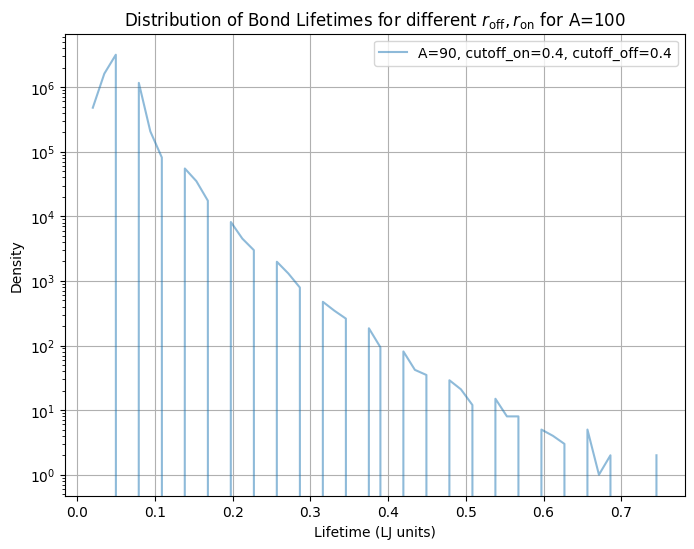

Processed lifetimes for A=90, cutoff_on=0.4, cutoff_off=0.5, total lifetimes recorded: 991826
Processed lifetimes for A=90, cutoff_on=0.5, cutoff_off=0.5, total lifetimes recorded: 1108905


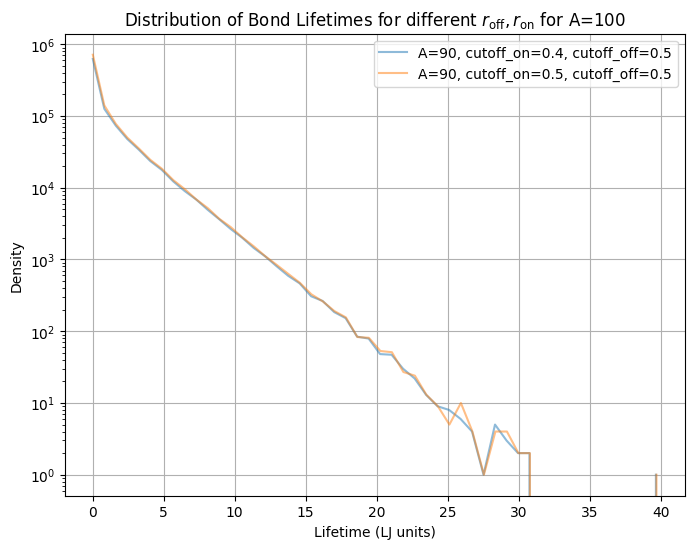

Processed lifetimes for A=90, cutoff_on=0.4, cutoff_off=0.6, total lifetimes recorded: 161901
Processed lifetimes for A=90, cutoff_on=0.5, cutoff_off=0.6, total lifetimes recorded: 188815
Processed lifetimes for A=90, cutoff_on=0.6, cutoff_off=0.6, total lifetimes recorded: 244020


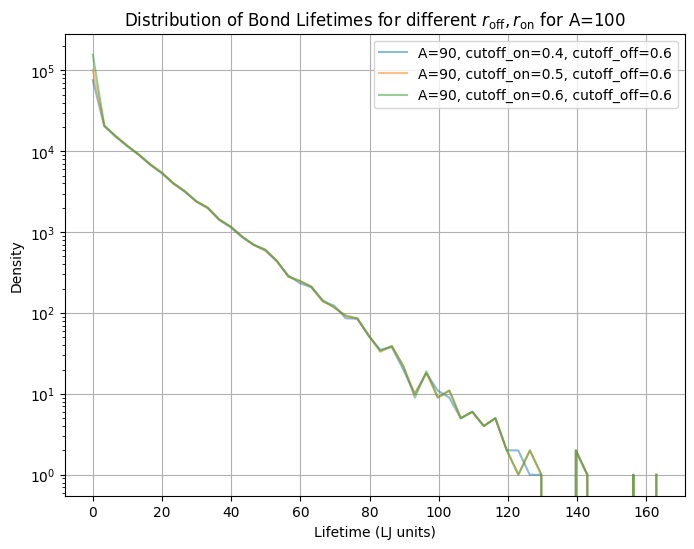

Processed lifetimes for A=90, cutoff_on=0.4, cutoff_off=0.7, total lifetimes recorded: 129772
Processed lifetimes for A=90, cutoff_on=0.5, cutoff_off=0.7, total lifetimes recorded: 174450
Processed lifetimes for A=90, cutoff_on=0.6, cutoff_off=0.7, total lifetimes recorded: 221405
Processed lifetimes for A=90, cutoff_on=0.7, cutoff_off=0.7, total lifetimes recorded: 412921


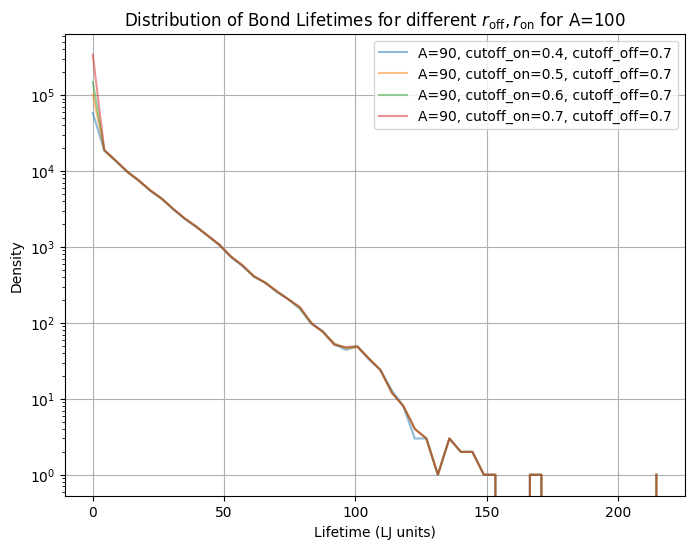

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# for cutoff in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
#     fig = plt.figure(figsize=(8, 6))
#     for A in [50, 60, 70, 80, 90, 100]:
#         df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff}_r0_0.25.csv")
#         lifetimes = np.array(df["lifetime"].values)
#         # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

#         values, counts = np.unique(lifetimes, return_counts=True)


#         plt.hist(values, weights=counts, bins=50, alpha=0.5, label=f"A={A}", density=True)
#     plt.xlabel("Lifetime (LJ units)")
#     plt.ylabel("Counts")
#     plt.grid()
#     plt.title(f"Distribution of Bond Lifetimes for cutoff={cutoff}")
#     plt.legend()
#     plt.show()

for cutoff_off in [0.4, 0.5, 0.6, 0.7]:
    fig = plt.figure(figsize=(8, 6))
    for cutoff_on in [0.4, 0.5, 0.6, 0.7]:
        if cutoff_on < cutoff_off:
            for A in [90]:
                df = pd.read_csv(f"data/lifetimes/buffered_lifetimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv")
                lifetimes = np.array(df["lifetime"].values)
                # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

                # values, counts = np.unique(lifetimes, return_counts=True)
                hist, bins = np.histogram(lifetimes, bins=50)


                plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
        if cutoff_on == cutoff_off:
            for A in [90]:
                df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff_on}_r0_0.25.csv")
                lifetimes = np.array(df["lifetime"].values)
                # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

                # values, counts = np.unique(lifetimes, return_counts=True)
                hist, bins = np.histogram(lifetimes, bins=50)


                plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
    plt.xlabel("Lifetime (LJ units)")
    plt.ylabel("Density")
    plt.yscale("log")
    # plt.ylim(0, 0.2)
    plt.grid()
    plt.title(r"Distribution of Bond Lifetimes for different $r_{\text{off}}, r_{\text{on}}$ for A=100")
    plt.legend()
    plt.show()

Processed lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.5, total lifetimes recorded: 28212
Removing, remaining lifetimes recorded: 18470
Fitted coefficients for A=130, cutoff_on=0.4, cutoff_off=0.5: [1.19833638e+03 2.97676878e-03 2.35406364e+03 2.97676648e-03]
Fitted lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.5: tau_1=335.93, tau_2=335.93
Processed lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.5, total lifetimes recorded: 30465
Removing, remaining lifetimes recorded: 18473
Fitted coefficients for A=130, cutoff_on=0.5, cutoff_off=0.5: [1.77821967e+03 2.97806000e-03 1.77601036e+03 2.97807067e-03]
Fitted lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.5: tau_1=335.79, tau_2=335.79


/tmp/ipykernel_1289448/85425238.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_1289448/85425238.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


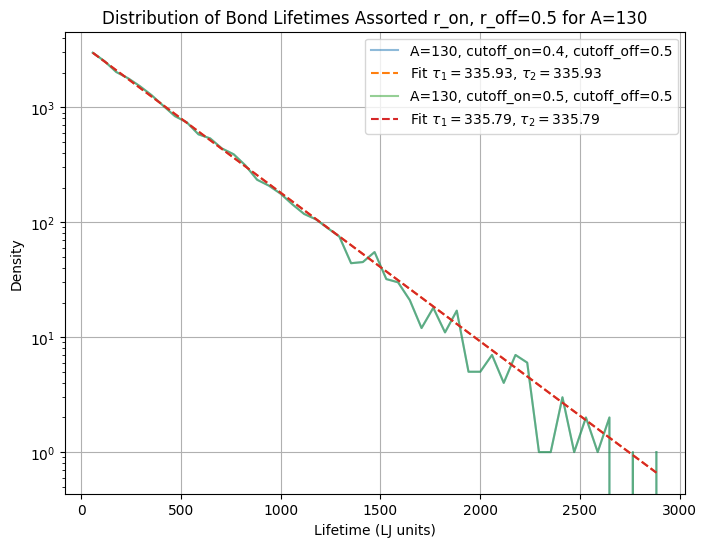

Processed lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.6, total lifetimes recorded: 2087
Removing, remaining lifetimes recorded: 1368
Fitted coefficients for A=130, cutoff_on=0.4, cutoff_off=0.6: [3.87255346e+01 2.72437866e-04 5.37499823e+01 9.45574647e-03]
Fitted lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.6: tau_1=105.76, tau_2=3670.56
Processed lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.6, total lifetimes recorded: 3791
Removing, remaining lifetimes recorded: 1368
Fitted coefficients for A=130, cutoff_on=0.5, cutoff_off=0.6: [3.87255346e+01 2.72437866e-04 5.37499823e+01 9.45574647e-03]
Fitted lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.6: tau_1=105.76, tau_2=3670.56
Processed lifetimes for A=130, cutoff_on=0.6, cutoff_off=0.6, total lifetimes recorded: 6718
Removing, remaining lifetimes recorded: 1368
Fitted coefficients for A=130, cutoff_on=0.6, cutoff_off=0.6: [3.87255346e+01 2.72437866e-04 5.37499823e+01 9.45574647e-03]
Fitted lifetimes for A=130, cutoff_on=0.

/tmp/ipykernel_1289448/85425238.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_1289448/85425238.py:8: RuntimeWarning: invalid value encountered in add
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_1289448/85425238.py:8: RuntimeWarning: overflow encountered in multiply
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_1289448/85425238.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_1289448/85425238.py:8: RuntimeWarning: invalid value encountered in add
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_1289448/85425238.py:8: RuntimeWarning: overflow encountered in multiply
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_1289448/85425238.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_1289448/85425238.py:

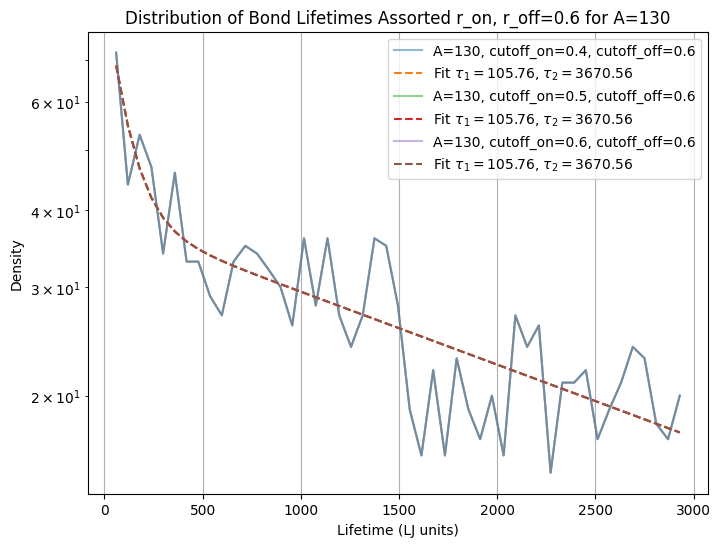

Processed lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.7, total lifetimes recorded: 5074
Removing, remaining lifetimes recorded: 2234
Fitted coefficients for A=130, cutoff_on=0.4, cutoff_off=0.7: [2.45726388e+02 8.79841920e-03 6.62391481e+01 4.03109610e-04]
Fitted lifetimes for A=130, cutoff_on=0.4, cutoff_off=0.7: tau_1=113.66, tau_2=2480.71
Processed lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.7, total lifetimes recorded: 6852
Removing, remaining lifetimes recorded: 2234
Fitted coefficients for A=130, cutoff_on=0.5, cutoff_off=0.7: [2.45726388e+02 8.79841920e-03 6.62391481e+01 4.03109610e-04]
Fitted lifetimes for A=130, cutoff_on=0.5, cutoff_off=0.7: tau_1=113.66, tau_2=2480.71
Processed lifetimes for A=130, cutoff_on=0.6, cutoff_off=0.7, total lifetimes recorded: 9483
Removing, remaining lifetimes recorded: 2234
Fitted coefficients for A=130, cutoff_on=0.6, cutoff_off=0.7: [2.45726388e+02 8.79841920e-03 6.62391481e+01 4.03109610e-04]
Fitted lifetimes for A=130, cutoff_on=0.

/tmp/ipykernel_1289448/85425238.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_1289448/85425238.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_1289448/85425238.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_1289448/85425238.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


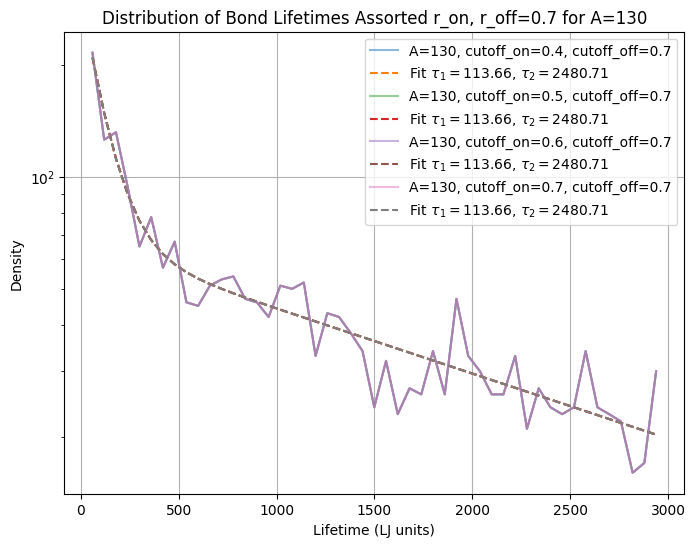

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def biexponential(x, a1, b1, a2, b2):
    return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)

def single_exponential(x, a, b):
    return a * np.exp(-b * x)




for cutoff_off in [ 0.5, 0.6, 0.7]:
    fig = plt.figure(figsize=(8, 6))
    for cutoff_on in [0.4, 0.5, 0.6, 0.7]:
        if cutoff_on < cutoff_off:
            for A in [130]:
                df = pd.read_csv(f"data/lifetimes/buffered_lifetimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv")
                lifetimes = np.array(df["lifetime"].values)
                # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

                # values, counts = np.unique(lifetimes, return_counts=True)
                hist, bins = np.histogram(lifetimes, bins=50)
                print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
                hist = hist[1:] # remove first bin
                bins = bins[1:] # remove first bin
                print(f"Removing, remaining lifetimes recorded: {np.sum(hist)}")

                coeffs, cov = curve_fit(biexponential, bins[:-1], hist, p0=[1, 0.01, 1, 0.01], maxfev=10000)
                print(f"Fitted coefficients for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: {coeffs}")
                tau_1, tau_2 = sorted((1/coeffs[1], 1/coeffs[3]))
                print(f"Fitted lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: tau_1={tau_1:.2f}, tau_2={tau_2:.2f}")

                plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                plt.plot(bins[:-1], biexponential(bins[:-1], *coeffs), '--', label=r"Fit $\tau_1=$" + f"{tau_1:.2f}" + r", $\tau_2=$" + f"{tau_2:.2f}")

                # coeffs, cov = curve_fit(single_exponential, bins[:-1], hist, p0=[1, 0.01])
                # print(f"Fitted coefficients for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: {coeffs}")
                # plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                # plt.plot(bins[:-1], single_exponential(bins[:-1], *coeffs), '--', label=f"Fit A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
            
            # plt.xlabel("Lifetime (LJ units)")
            # plt.ylabel("Density")
            # # plt.yscale("log")
            # # plt.ylim(0, 0.2)
            # plt.grid()
            # plt.title(f"Distribution of Bond Lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
            # plt.legend()
            # plt.show()
            
        if cutoff_on == cutoff_off:
            for A in [130]:
                df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff_on}_r0_0.25.csv")
                lifetimes = np.array(df["lifetime"].values)
                # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

                # values, counts = np.unique(lifetimes, return_counts=True)
                hist, bins = np.histogram(lifetimes, bins=50)


                print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
                hist = hist[1:] # remove first bin
                bins = bins[1:] # remove first bin
                print(f"Removing, remaining lifetimes recorded: {np.sum(hist)}")

                coeffs, cov = curve_fit(biexponential, bins[:-1], hist, p0=[1, 0.01, 1, 0.01], maxfev=10000)
                print(f"Fitted coefficients for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: {coeffs}")
                tau_1, tau_2 = sorted((1/coeffs[1], 1/coeffs[3]))
                print(f"Fitted lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: tau_1={tau_1:.2f}, tau_2={tau_2:.2f}")

                
                plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                plt.plot(bins[:-1], biexponential(bins[:-1], *coeffs), '--', label=r"Fit $\tau_1=$" + f"{tau_1:.2f}" + r", $\tau_2=$" + f"{tau_2:.2f}")

                # coeffs, cov = curve_fit(single_exponential, bins[:-1], hist, p0=[1, 0.01])
                # print(f"Fitted coefficients for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: {coeffs}")
                # plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                # plt.plot(bins[:-1], single_exponential(bins[:-1], *coeffs), '--', label=f"Fit A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                
            # plt.xlabel("Lifetime (LJ units)")
            # plt.ylabel("Density")
            # # plt.yscale("log")
            # # plt.ylim(0, 0.2)
            # plt.grid()
            # plt.title(f"Distribution of Bond Lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
            # plt.legend()
            # plt.show()
    plt.xlabel("Lifetime (LJ units)")
    plt.ylabel("Density")
    plt.yscale("log")
    # plt.ylim(0, 0.2)
    plt.grid()
    plt.title(f"Distribution of Bond Lifetimes Assorted r_on, r_off={cutoff_off} for A={A}")
    plt.legend()
    plt.show()

Processed lifetimes for A=100, cutoff_on=0.4, cutoff_off=0.5, total lifetimes recorded: 570528
Processed lifetimes for A=100, cutoff_on=0.4, cutoff_off=0.6, total lifetimes recorded: 59646
Processed lifetimes for A=100, cutoff_on=0.4, cutoff_off=0.7, total lifetimes recorded: 59891
Processed lifetimes for A=100, cutoff_on=0.5, cutoff_off=0.6, total lifetimes recorded: 70810
Processed lifetimes for A=100, cutoff_on=0.5, cutoff_off=0.7, total lifetimes recorded: 83394
Processed lifetimes for A=100, cutoff_on=0.6, cutoff_off=0.7, total lifetimes recorded: 108486


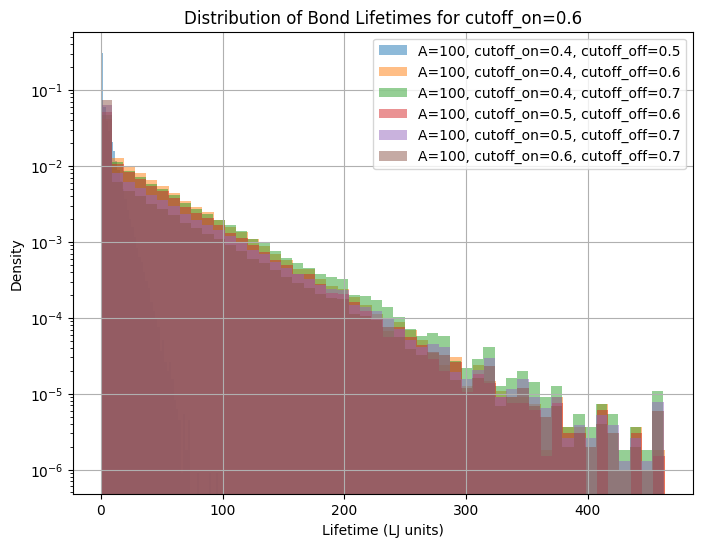

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# for cutoff in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
#     fig = plt.figure(figsize=(8, 6))
#     for A in [50, 60, 70, 80, 90, 100]:
#         df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff}_r0_0.25.csv")
#         lifetimes = np.array(df["lifetime"].values)
#         # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

#         values, counts = np.unique(lifetimes, return_counts=True)


#         plt.hist(values, weights=counts, bins=50, alpha=0.5, label=f"A={A}", density=True)
#     plt.xlabel("Lifetime (LJ units)")
#     plt.ylabel("Counts")
#     plt.grid()
#     plt.title(f"Distribution of Bond Lifetimes for cutoff={cutoff}")
#     plt.legend()
#     plt.show()
fig = plt.figure(figsize=(8, 6))
for cutoff_on in [0.4, 0.5, 0.6]:
    
    for cutoff_off in [0.4, 0.5, 0.6, 0.7]:
        if cutoff_on < cutoff_off:
            for A in [100]:
                df = pd.read_csv(f"data/lifetimes/buffered_lifetimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv")
                lifetimes = np.array(df["lifetime"].values)
                # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

                # values, counts = np.unique(lifetimes, return_counts=True)


                plt.hist(lifetimes, bins=50, alpha=0.5,density=True, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
plt.xlabel("Lifetime (LJ units)")
plt.ylabel("Density")
plt.yscale("log")
# plt.ylim(0, 0.2)
plt.grid()
plt.title(f"Distribution of Bond Lifetimes for cutoff_on={cutoff_on}")
plt.legend()
plt.show()